In [1]:
# Loaded variable 'df' from URI: c:\Users\03tom\Downloads\RP2021_mobpro\FD_MOBPRO_2021.csv
import pandas as pd
df = pd.read_csv(r'c:\Users\03tom\Downloads\RP2021_mobpro\FD_MOBPRO_2021.csv', sep=';')
df.head()

C:\Users\03tom\AppData\Local\Temp\ipykernel_19864\3461116030.py:3: DtypeWarning: Columns (0,1,2,3,13,14,15,17,21,23,26,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'c:\Users\03tom\Downloads\RP2021_mobpro\FD_MOBPRO_2021.csv', sep=';')


,COMMUNE,ARM,DCFLT,DCLT,AGEREVQ,CS1,DEROU,DIPL,EMPL,ILT,...,REGION,REGLT,SEXE,STAT,STOCD,TP,TRANS,TYPL,TYPMR,VOIT
0,1001,ZZZZZ,99999,1001,55,1,Z,15,21,1,...,84,84,1,21,10,1,5,1,41,2
1,1001,ZZZZZ,99999,1001,25,5,Z,14,16,1,...,84,84,2,10,10,1,1,1,41,2
2,1001,ZZZZZ,99999,1001,35,4,Z,17,16,1,...,84,84,2,10,10,1,5,1,41,2
3,1001,ZZZZZ,99999,1001,45,5,Z,14,16,1,...,84,84,2,10,22,2,5,2,12,1
4,1001,ZZZZZ,99999,1001,20,2,Z,14,21,1,...,84,84,2,21,10,1,1,1,41,3


(32373, 32)
count    32373.000000
mean        68.460754
std          5.496619
min         65.000000
25%         65.000000
50%         65.000000
75%         70.000000
max        110.000000
Name: AGEREVQ, dtype: float64
COMMUNE
75056    11605
92012      509
92051      495
93048      310
94068      304
         ...  
77199        1
77202        1
77203        1
77211        1
77378        1
Name: count, Length: 932, dtype: int64


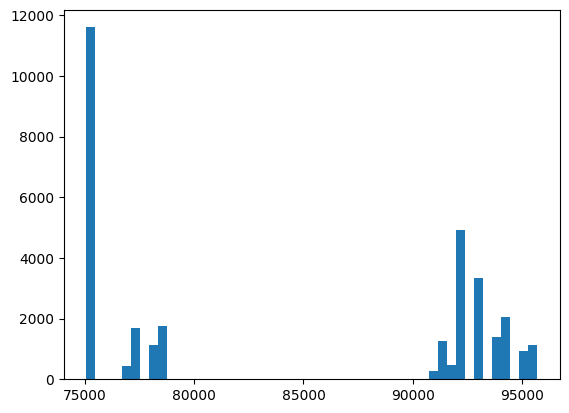

In [2]:
df = df[df["AGEREVQ"] >= 65]
df = df[df["REGION"] == 11]
#eliminar para la columna COMMUNE el valor '75056
#df = df[df["COMMUNE"] != 75056]
print(df.shape)
print(df["AGEREVQ"].describe())
print(df["COMMUNE"].value_counts())

# print histogram for COMMUNE
import matplotlib.pyplot as plt
plt.hist(df["COMMUNE"], bins=50)
plt.show()

columnas: Index(['n_sq_ar', 'c_ar', 'c_arinsee', 'l_ar', 'l_aroff', 'n_sq_co', 'surface',
       'perimetre', 'geometry'],
      dtype='object')
cantidad de comunas en el shapefile: 20


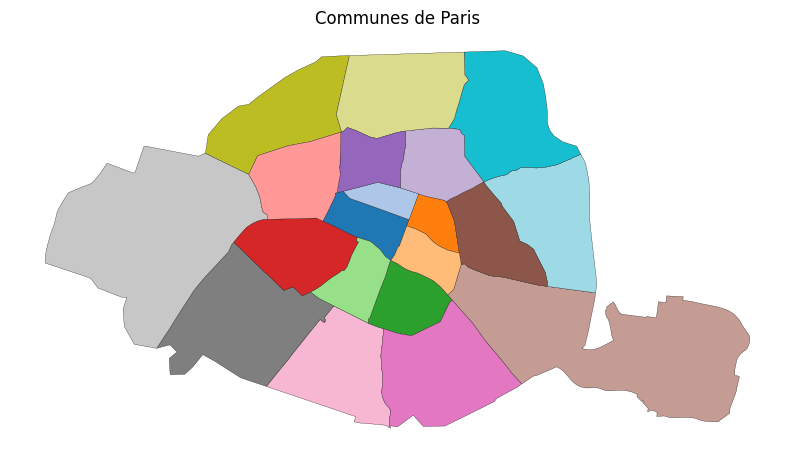

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Leer el shapefile
RUTA_SHP_COMMUNES = "arrondissements.shp"
communes_gdf = gpd.read_file(RUTA_SHP_COMMUNES)

#ver las columnas y cantidad de comunas
print("columnas:", communes_gdf.columns)
print("cantidad de comunas en el shapefile:", len(communes_gdf))
#print("Columnas del shapefile:", communes_gdf.columns)
#print("Ejemplo códigos c_arinsee:", communes_gdf["c_arinsee"])

# Plotear cada comuna con un color distinto
fig, ax = plt.subplots(figsize=(10, 10))
communes_gdf.plot(
    column="c_arinsee",   # usar el código como categoría
    categorical=True,
    legend=False,
    cmap="tab20",         # paleta de colores categórica
    ax=ax,
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Communes de Paris")
ax.axis("off")
plt.show()


   objectid    shape_leng    insee            nomcom  numdep fusioinsee  \
0      50.0   7852.428895  94052.0  Nogent-sur-Marne    94.0       None   
1      52.0   8504.785189  93070.0        Saint-Ouen    93.0       None   
2     202.0   9268.688667  78076.0          Boissets    78.0       None   
3     388.0  12861.890802  78478.0   Paray-Douaville    78.0       None   
4     395.0  10599.492149  95341.0        Livilliers    95.0       None   

           nomcomto  st_areasha    st_lengths  \
0  Nogent-sur-Marne   3138180.0   7852.428895   
1        Saint-Ouen   4532818.0   8504.785189   
2          Boissets   4147954.5   9268.688667   
3   Paray-Douaville  10027953.5  12861.890802   
4        Livilliers   6449849.5  10599.492149   

                                            geometry  
0  POLYGON ((2.46576 48.82628, 2.46725 48.83909, ...  
1  POLYGON ((2.31988 48.90046, 2.31376 48.91402, ...  
2  POLYGON ((1.58662 48.8432, 1.57727 48.84436, 1...  
3  POLYGON ((1.87944 48.44067, 1.8

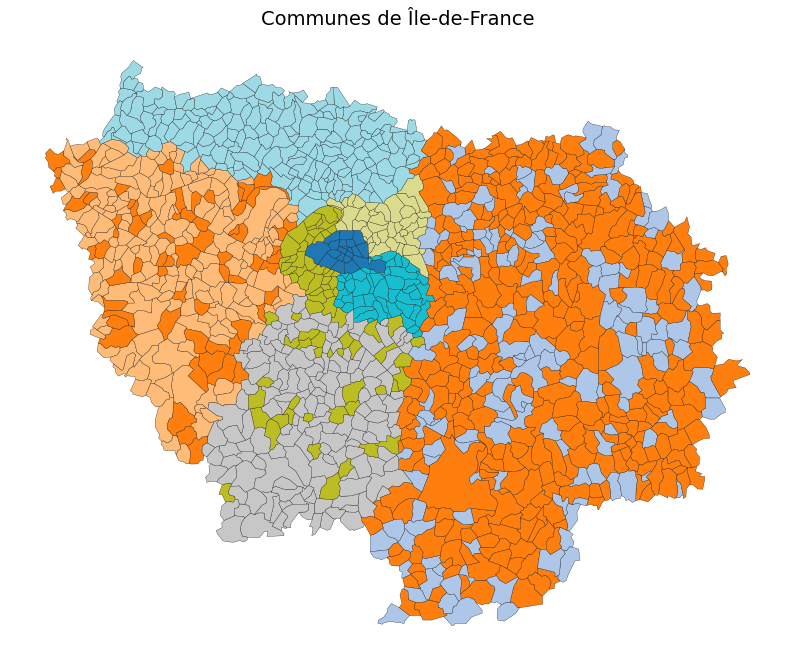

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar shapefile
shapefile_path = "communes-dile-de-france-au-01-janvier.shp"  # reemplazá con la ruta real
gdf = gpd.read_file(shapefile_path)

print(gdf.head())
print("Cantidad de comunas:", len(gdf))

# Plotear todas las comunas
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, column="insee", cmap="tab20", legend=False, edgecolor="black", linewidth=0.2)

ax.set_title("Communes de Île-de-France", fontsize=14)
ax.axis("off")
plt.show()

In [5]:
counts = df.groupby("COMMUNE").size().reset_index(name="count_over65")
counts_sorted = counts.sort_values(by="count_over65", ascending=False)

gdf["insee"] = gdf["insee"].astype(float).astype(int).astype(str)
counts_sorted["COMMUNE"] = counts_sorted["COMMUNE"].astype(int).astype(str)

print(gdf.columns.tolist())
gdf = gdf.merge(counts_sorted, left_on="insee", right_on="COMMUNE", how="left")
print(gdf.columns.tolist())

gdf["count_over65"] = gdf["count_over65"].fillna(0).astype(int)
print(gdf[["insee", "count_over65"]].head(10))
print("cantidad de personas mayores de 65:", gdf["count_over65"].sum())

['objectid', 'shape_leng', 'insee', 'nomcom', 'numdep', 'fusioinsee', 'nomcomto', 'st_areasha', 'st_lengths', 'geometry']
['objectid', 'shape_leng', 'insee', 'nomcom', 'numdep', 'fusioinsee', 'nomcomto', 'st_areasha', 'st_lengths', 'geometry', 'COMMUNE', 'count_over65']
   insee  count_over65
0  94052           118
1  93070           133
2  78076             0
3  78478             1
4  95341             0
5  77344             2
6  95365             1
7  78591             5
8  78123            30
9  78655             1
cantidad de personas mayores de 65: 20768


      insee  count_over65
25    92012           509
1101  92051           495
421   93048           310
153   94068           304
277   78646           286
1237  94028           277
356   92026           243
617   92004           228
1200  92044           218
1250  93066           205


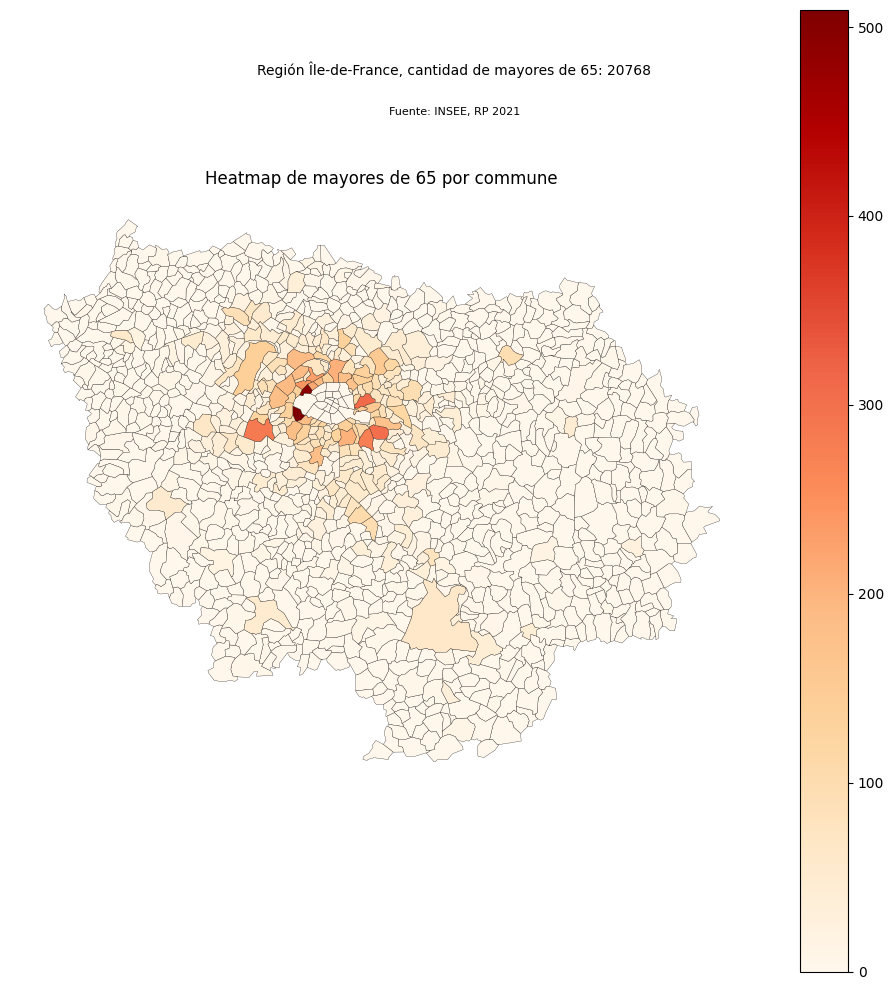

In [17]:
#PRINTEAR DE FORMA DESCENDENTE
print(gdf[["insee", "count_over65"]].sort_values(by="count_over65", ascending=False).head(10))

# Plotear el shapefile con un heatmap basado en count_over65
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(
    ax=ax,
    column="count_over65",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2
)
ax.set_title("Heatmap de mayores de 65 por commune")
# Para dos subtítulos uno debajo del otro, usa fig.text en diferentes posiciones verticales
fig.text(0.5, 0.92, f"Región Île-de-France, cantidad de mayores de 65: {gdf['count_over65'].sum()}", ha='center', fontsize=10)
fig.text(0.5, 0.88, "Fuente: INSEE, RP 2021", ha='center', fontsize=8)
fig.tight_layout()
ax.axis("off")
plt.show()

## Extra

In [7]:
# --- Celda 6: Agregación 65+ por commune (con pesos) ---
import pandas as pd
import numpy as np

# Copia de trabajo para no modificar df original accidentalmente
_df = df.copy()

# Si AGEREVQ representa edad real en años ya sirve; si es código de quinquenio, reemplaza 'AGEREVQ' por edad media estimada.
# Placeholder: si los valores son mayores a 120 interpretamos que es codificación y habría que mapear.
if _df['AGEREVQ'].max() < 120:
    edad_num = _df['AGEREVQ']
else:
    # Ejemplo de mapping (AJUSTAR según diccionario oficial INSEE)
    mapping_demo = {11:55,12:60,13:65,14:70,15:75,16:80,17:85,18:90}
    edad_num = _df['AGEREVQ'].map(mapping_demo)

_df['is_65_plus'] = edad_num >= 65

# Pesos
_df['peso'] = _df['IPONDI'] if 'IPONDI' in _df.columns else 1.0

# Verificación de columnas clave
if 'COMMUNE' not in _df.columns:
    raise ValueError('No se encontró la columna COMMUNE (código INSEE de residencia).')

agg_commune = (
    _df.groupby('COMMUNE')
        .apply(lambda g: pd.Series({
            'seniors_w': g.loc[g['is_65_plus'], 'peso'].sum(),
            'total_w': g['peso'].sum()
        }))
        .reset_index()
)
agg_commune['share_65_plus'] = agg_commune['seniors_w'] / agg_commune['total_w']

print(agg_commune.head())
print('Comun(es) totales:', len(agg_commune))

   COMMUNE     seniors_w       total_w  share_65_plus
0    75056  38136.538468  38136.538468            1.0
1    77001     15.184439     15.184439            1.0
2    77003      4.961539      4.961539            1.0
3    77005     14.793890     14.793890            1.0
4    77007      5.424158      5.424158            1.0
Comun(es) totales: 932


C:\Users\03tom\AppData\Local\Temp\ipykernel_19864\742195654.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Columnas shapefile: ['n_sq_ar', 'c_ar', 'c_arinsee', 'l_ar', 'l_aroff', 'n_sq_co', 'surface', 'perimetre', 'geometry']
Primeros códigos c_arinsee: ['75101', '75103', '75114', '75117', '75105']
Ejemplo mapeo arrondissement->commune:
  c_arinsee COMMUNE_EQ
0     75101      75056
1     75103      75056
2     75114      75056
3     75117      75056
4     75105      75056
Total claves en shapefile (arr nivel convertidas): 1 | en datos agg: 932 | intersección: 1
Filas merge: 20 | Con dato 65+: 20


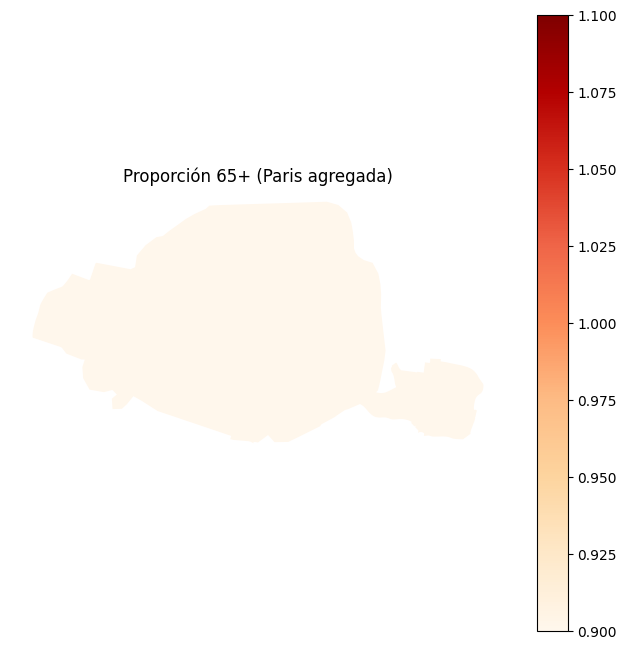

In [8]:
# --- Celda 7 (robusta): Arrondissements -> commune y merge share_65_plus ---
import re
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

RUTA_SHP_COMMUNES = 'arrondissements.shp'
communes_gdf = gpd.read_file(RUTA_SHP_COMMUNES)
print('Columnas shapefile:', list(communes_gdf.columns))
print('Primeros códigos c_arinsee:', communes_gdf['c_arinsee'].head().tolist())

if 'c_arinsee' not in communes_gdf.columns:
    raise ValueError('El shapefile no tiene la columna c_arinsee esperada.')

# Normalizar columna original (string y padding si hiciera falta)
communes_gdf['c_arinsee'] = communes_gdf['c_arinsee'].astype(str).str.strip()

# Función para mapear arrondissements a código de commune (Paris/Lyon/Marseille)
pat_paris = re.compile(r'751\d{2}')
pat_lyon = re.compile(r'6938\d')
pat_marseille = re.compile(r'132\d{2}')

def arrondissement_a_commune(code: str) -> str:
    if pat_paris.fullmatch(code):
        return '75056'
    if pat_lyon.fullmatch(code):
        return '69123'
    if pat_marseille.fullmatch(code):
        return '13055'
    return code

communes_gdf['COMMUNE_EQ'] = communes_gdf['c_arinsee'].apply(arrondissement_a_commune)
# Asegurar padding a 5 (algunas comunas DOM pueden ser 5 letras/nums ya). Si >5 no tocamos.
communes_gdf['COMMUNE_EQ'] = communes_gdf['COMMUNE_EQ'].apply(lambda x: x if len(x) != 5 else x)

# Normalizar tipos en agg_commune: convertir a string y quitar espacios / padding
agg_commune['COMMUNE'] = agg_commune['COMMUNE'].astype(str).str.strip()
print('Ejemplo mapeo arrondissement->commune:')
print(communes_gdf[['c_arinsee','COMMUNE_EQ']].head())

# Verificar intersección de claves
claves_shape = set(communes_gdf['COMMUNE_EQ'].unique())
claves_data = set(agg_commune['COMMUNE'].unique())
inter = claves_shape & claves_data
print(f'Total claves en shapefile (arr nivel convertidas): {len(claves_shape)} | en datos agg: {len(claves_data)} | intersección: {len(inter)}')
if len(inter) == 0:
    raise ValueError('No hubo coincidencias entre códigos del shapefile y agg_commune. Revisa que REGION==11 realmente corresponde al área del shapefile y que los códigos tengan formato correcto.')

# Merge
merge_gdf = communes_gdf.merge(agg_commune, left_on='COMMUNE_EQ', right_on='COMMUNE', how='left')

# Reporte de faltantes
faltantes = merge_gdf['share_65_plus'].isna().sum()
if faltantes > 0:
    sample_missing = merge_gdf.loc[merge_gdf['share_65_plus'].isna(), 'COMMUNE_EQ'].head().tolist()
    print(f'Aviso: {faltantes} arrondissements/comunas sin dato (p.ej: {sample_missing})')

print('Filas merge:', len(merge_gdf), '| Con dato 65+:', merge_gdf['share_65_plus'].notna().sum())

# Opción para disolver por commune (un polígono por COMMUNE_EQ)
# Si la mayoría son arrondissements de Paris, disolver para no repetir mismo valor
solo_paris = set(communes_gdf['COMMUNE_EQ']) == {'75056'}
if solo_paris:
    # No aporta mucho mapa; mostramos solo el polígono disuelto
    plot_gdf = merge_gdf.dissolve(by='COMMUNE_EQ', aggfunc='first').reset_index()
    titulo = 'Proporción 65+ (Paris agregada)'
else:
    # Puedes cambiar a disolver si prefieres una geometría por commune
    # plot_gdf = merge_gdf.dissolve(by='COMMUNE_EQ', aggfunc='first').reset_index()
    # titulo = 'Proporción 65+ (geometría commune)'
    plot_gdf = merge_gdf
    titulo = 'Proporción 65+ (arrondissements, valor comunal)'

fig, ax = plt.subplots(1,1, figsize=(8,8))
plot_gdf.plot(column='share_65_plus', cmap='OrRd', legend=True, ax=ax,
              missing_kwds={'color':'lightgrey','label':'Sin dato'})
ax.set_title(titulo)
ax.axis('off')
plt.show()

Rango absoluto: 1.000000 – 1.000000 (Δ=0.000000) | Media=1.000000 | N=1
Distribución prácticamente constante: usando color único y mapa de diferencias omitido.


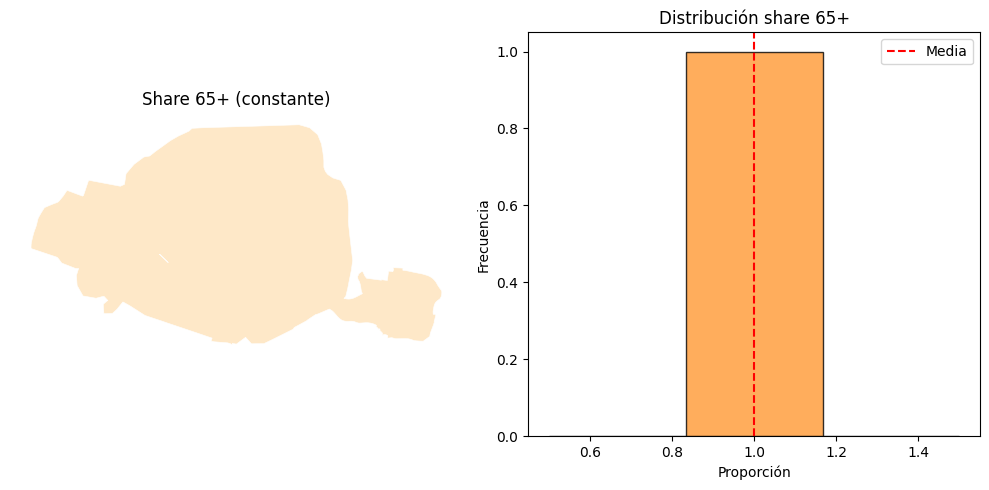

In [9]:
# --- Celda 7b (revisada): Visualización avanzada de share_65_plus ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

if 'plot_gdf' not in globals():
    raise RuntimeError('Ejecuta primero la celda 7 para construir plot_gdf.')
if 'share_65_plus' not in plot_gdf.columns:
    raise RuntimeError('La columna share_65_plus no está disponible. Revisa celdas previas.')

vals = plot_gdf['share_65_plus'].dropna()
if vals.empty:
    print('Sin valores para visualizar.')
else:
    vmin, vmax = float(vals.min()), float(vals.max())
    mean_v = float(vals.mean())
    rng = vmax - vmin
    print(f'Rango absoluto: {vmin:.6f} – {vmax:.6f} (Δ={rng:.6f}) | Media={mean_v:.6f} | N={len(vals)}')

    plot_gdf = plot_gdf.copy()
    plot_gdf['share_pct'] = plot_gdf['share_65_plus'] * 100
    plot_gdf['diff_pct'] = (plot_gdf['share_65_plus'] - mean_v) / (mean_v + 1e-12) * 100  # % sobre media

    # Detectar caso degenerado (todos iguales o casi)
    degenerado = rng == 0 or (mean_v != 0 and rng/mean_v < 1e-4)
    if degenerado:
        print('Distribución prácticamente constante: usando color único y mapa de diferencias omitido.')

    # Cuantiles para clasificación cuando no es degenerado
    if not degenerado:
        try:
            qs = np.unique(vals.quantile([0,0.2,0.4,0.6,0.8,1.0]).values)
        except Exception:
            qs = np.linspace(vmin, vmax, 6)
        # Eliminar cuantiles repetidos (si colapsan)
        qs = np.unique(qs)
        if len(qs) < 3:  # aún demasiado pocos límites
            degenerado = True
            print('Cuantiles colapsaron -> tratamos como distribución constante.')
    else:
        qs = np.array([vmin, vmax])

    # Preparar figura
    cols = 3 if not degenerado else 2  # hist siempre, mapa absoluto siempre, divergente solo si no degenerado
    fig, axs = plt.subplots(1, cols, figsize=(5*cols, 5))
    if cols == 2:
        ax_map = axs[0]
        ax_hist = axs[1]
    else:
        ax_map = axs[0]
        ax_div = axs[1]
        ax_hist = axs[2]

    # 1. Mapa absoluto
    if degenerado:
        # Color fijo
        const_cmap = mpl.colors.ListedColormap(['#fee8c8'])
        plot_gdf.plot(column='share_65_plus', cmap=const_cmap, linewidth=0.4, edgecolor='white', ax=ax_map)
        ax_map.set_title('Share 65+ (constante)')
    else:
        cmap_abs = plt.get_cmap('YlOrRd')
        # Asegurar boundaries correctos para BoundaryNorm
        norm_abs = mpl.colors.BoundaryNorm(qs, cmap_abs.N, extend='neither')
        plot_gdf.plot(column='share_65_plus', cmap=cmap_abs, norm=norm_abs, linewidth=0.4, edgecolor='white', ax=ax_map)
        ax_map.set_title('Share 65+ (cuantiles)')
        # Colorbar seguro (solo si hay >2 límites únicos)
        if len(qs) > 2:
            try:
                cbar0 = fig.colorbar(mpl.cm.ScalarMappable(norm=norm_abs, cmap=cmap_abs), ax=ax_map, fraction=0.04)
                cbar0.ax.set_ylabel('Proporción')
            except Exception as e:
                print('No se pudo crear colorbar absoluto:', e)
    ax_map.axis('off')

    # 2. Mapa divergente (% vs media)
    if not degenerado:
        cmap_div = plt.get_cmap('RdBu_r')
        max_abs_diff = float(np.nanmax(np.abs(plot_gdf['diff_pct']))) if not plot_gdf['diff_pct'].dropna().empty else 1.0
        if max_abs_diff == 0:
            max_abs_diff = 1.0
        norm_div = mpl.colors.TwoSlopeNorm(vmin=-max_abs_diff, vcenter=0, vmax=max_abs_diff)
        plot_gdf.plot(column='diff_pct', cmap=cmap_div, norm=norm_div, linewidth=0.4, edgecolor='white', ax=ax_div)
        ax_div.set_title('% sobre la media (65+)')
        ax_div.axis('off')
        try:
            cbar1 = fig.colorbar(mpl.cm.ScalarMappable(norm=norm_div, cmap=cmap_div), ax=ax_div, fraction=0.04)
            cbar1.ax.set_ylabel('% vs media')
        except Exception as e:
            print('No se pudo crear colorbar divergente:', e)

    # 3. Histograma
    ax_hist.hist(vals, bins=min(30, max(3, len(vals)//2)), color='#ff9933', edgecolor='black', alpha=0.8)
    ax_hist.axvline(mean_v, color='red', linestyle='--', label='Media')
    if not degenerado:
        for q in [0.2,0.4,0.6,0.8]:
            ax_hist.axvline(vals.quantile(q), color='grey', linestyle=':', alpha=0.6)
    ax_hist.set_title('Distribución share 65+')
    ax_hist.set_xlabel('Proporción')
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.legend()

    # 4. Etiquetas (si hay suficientes polígonos y no degenerado)
    if len(plot_gdf) > 3:
        try:
            centroids = plot_gdf.geometry.representative_point()  # más robusto que centroid para polígonos multiparte
            plot_gdf = plot_gdf.assign(_x=centroids.x, _y=centroids.y)
            if degenerado:
                mostrar = plot_gdf.sample(min(3, len(plot_gdf)))
            else:
                orden = plot_gdf.sort_values('share_65_plus')
                mostrar = pd.concat([orden.head(min(3, len(orden))), orden.tail(min(3, len(orden)))])
            for _, r in mostrar.iterrows():
                ax_map.text(r['_x'], r['_y'], f"{r['share_65_plus']*100:.1f}%", ha='center', va='center', fontsize=7, color='black')
                if not degenerado and cols == 3:
                    ax_div.text(r['_x'], r['_y'], f"{r['diff_pct']:.1f}%", ha='center', va='center', fontsize=7, color='black')
        except Exception as e:
            print('No se pudieron generar etiquetas:', e)

    plt.tight_layout()
    plt.show()

In [10]:
# --- Celda 8: Rasterización de share_65_plus a grilla 50x50 y métricas comparativas ---
import numpy as np
from shapely.geometry import box
from shapely.strtree import STRtree

# Construimos celdas de la grilla como polígonos en bounding box ya usado para P_pred
lon_edges = np.linspace(min_lon, max_lon, GRID_N+1)
lat_edges = np.linspace(min_lat, max_lat, GRID_N+1)

# Preparamos spatial index de communes (solo las que tienen valor)
communes_valid = merge_gdf[~merge_gdf['share_65_plus'].isna()].copy()
geoms = communes_valid.geometry.to_list()
shares = communes_valid['share_65_plus'].to_numpy()
index = STRtree(geoms)

raster_share = np.zeros((GRID_N, GRID_N), dtype=float)

# Para cada celda: calculamos intersección con polígonos y agregamos área ponderada * share
for iy in range(GRID_N):
    for ix in range(GRID_N):
        cell_poly = box(lon_edges[ix], lat_edges[iy], lon_edges[ix+1], lat_edges[iy+1])
        cand = index.query(cell_poly)
        total_area = 0.0
        val = 0.0
        for poly in cand:
            inter = cell_poly.intersection(poly)
            if not inter.is_empty:
                a = inter.area
                # Recuperar share correspondiente
                share_val = shares[geoms.index(poly)]
                val += share_val * a
                total_area += a
        if total_area > 0:
            raster_share[iy, ix] = val / total_area  # promedio ponderado por área

# Normalizamos la capa externa socio-demográfica como probabilidad espacial (opcional)
P_ext_65 = raster_share.copy()
# Evitar división si todo es cero
if P_ext_65.sum() > 0:
    P_ext_65 = P_ext_65 / P_ext_65.sum()

# Métricas comparando P_pred vs P_ext_65
flat_pred2 = P_pred.ravel()
flat_ext2 = P_ext_65.ravel()
mask_valid = flat_ext2 > 0  # opcional: solo celdas con dato

pearson2 = np.corrcoef(flat_pred2[mask_valid], flat_ext2[mask_valid])[0,1] if mask_valid.sum()>2 else np.nan
rank_pred2 = flat_pred2.argsort().argsort()
rank_ext2 = flat_ext2.argsort().argsort()
spearman2 = np.corrcoef(rank_pred2[mask_valid], rank_ext2[mask_valid])[0,1] if mask_valid.sum()>2 else np.nan

from scipy.spatial.distance import jensenshannon
jsd2 = jensenshannon(flat_pred2 + 1e-15, flat_ext2 + 1e-15, base=2)**2
overlap2 = np.minimum(flat_pred2, flat_ext2).sum()

def precision_at_k_idx(Pa, Pb, k=25):
    idx_a = np.argsort(Pa)[-k:]
    idx_b = np.argsort(Pb)[-k:]
    return len(set(idx_a) & set(idx_b)) / k

p_at_25 = precision_at_k_idx(flat_pred2, flat_ext2, 25)

metricas_65 = {
    'pearson': pearson2,
    'spearman': spearman2,
    'jsd': jsd2,
    'overlap': overlap2,
    'precision@25': p_at_25
}
print(metricas_65)

# Visual rápido
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,3, figsize=(15,4))
axs[0].imshow(P_pred, cmap='viridis'); axs[0].set_title('P_pred')
axs[1].imshow(P_ext_65, cmap='viridis'); axs[1].set_title('P_ext_65 (share 65+)')
res2 = P_pred - P_ext_65
vmax2 = np.max(np.abs(res2))
axs[2].imshow(res2, cmap='bwr', vmin=-vmax2, vmax=vmax2); axs[2].set_title('Residuales')
for ax in axs: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
metricas_65

NameError: name 'min_lon' is not defined

### Resumen validación socio-demográfica (+65) vs heatmap movilidad

Flujo implementado:
1. Filtro y etiqueto individuos 65+ usando `AGEREVQ` (o mapping si es código).
2. Agrego por `COMMUNE` con pesos `IPONDI` para obtener proporción `share_65_plus`.
3. Uno con shapefile de communes (Ile-de-France) y visualizo choropleth.
4. Rasterizo la capa comunal a la misma grilla 50×50 de `P_pred`.
5. Calculo métricas: Pearson, Spearman, JSD, Overlap, Precision@25.
6. Visualizo residuales espaciales.

Esto sirve como validación estructural: si el patrón de presencia de tus usuarios (P_pred) correlaciona con la concentración de mayores, indica coherencia con la base poblacional.

Siguientes ampliaciones posibles:
- Repetir para otras capas: ejecutivos (filtrar por `CS1`), inmigrantes (`IMMI`), nivel educativo (`DIPL`).
- Bootstrap sobre individuos para intervalos de confianza de las métricas.
- Incorporar corrección de autocorrelación espacial (Moran’s I de residuales).
- Guardar resultados en una tabla consolidada (un DataFrame por segmento).

## Extra

In [ ]:
# --- Celda 3: Construcción de heatmap (predicción) en grilla 50x50 ---
import numpy as np

# Detectamos columnas de coordenadas (ajusta si es necesario)
COL_LON_CANDIDATAS = ['lon','Lon','LON','longitude','LONGITUDE','X','x']
COL_LAT_CANDIDATAS = ['lat','Lat','LAT','latitude','LATITUDE','Y','y']

def _detectar_col(df, candidatos):
    for c in candidatos:
        if c in df.columns:
            return c
    raise ValueError(f"No se encontró ninguna de las columnas: {candidatos}")

COL_LON = _detectar_col(df, COL_LON_CANDIDATAS)
COL_LAT = _detectar_col(df, COL_LAT_CANDIDATAS)
print('Usando columnas de coordenadas:', COL_LON, COL_LAT)

GRID_N = 50  # grilla 50x50
min_lon, max_lon = df[COL_LON].min(), df[COL_LON].max()
min_lat, max_lat = df[COL_LAT].min(), df[COL_LAT].max()
print('Bounding Box:', (min_lon, min_lat, max_lon, max_lat))

# Función para mapear coordenadas a índices de celda
def coord_a_idx(lon_arr, lat_arr):
    ix = ((lon_arr - min_lon) / (max_lon - min_lon + 1e-12) * GRID_N).astype(int)
    iy = ((lat_arr - min_lat) / (max_lat - min_lat + 1e-12) * GRID_N).astype(int)
    ix = np.clip(ix, 0, GRID_N-1)
    iy = np.clip(iy, 0, GRID_N-1)
    return ix, iy

ix, iy = coord_a_idx(df[COL_LON].to_numpy(), df[COL_LAT].to_numpy())
heat_pred_counts = np.zeros((GRID_N, GRID_N), dtype=float)
for x_, y_ in zip(ix, iy):
    heat_pred_counts[y_, x_] += 1  # fila=y, columna=x

P_pred = heat_pred_counts / heat_pred_counts.sum()
print('Suma P_pred =', P_pred.sum())
# --- Celda 4: Capa externa sintética (placeholder INSEE / empleo) y métricas ---
# En esta celda se simula una capa externa (P_ext) hasta que incorpores datos reales.
# Reemplazo futuro: cargar shapefile/CSV oficial, reproyectar y rasterizar a la misma grilla.

import numpy as np
from scipy.spatial.distance import jensenshannon

# Placeholder: suavizamos y desplazamos ligeramente P_pred para simular diferencias
from scipy.ndimage import gaussian_filter
P_ext_raw = gaussian_filter(P_pred, sigma=2)
# Introducir un sesgo espacial artificial (gradiente)
gradiente = np.linspace(0.8, 1.2, P_ext_raw.shape[1])  # variación este-oeste
P_ext_biased = P_ext_raw * gradiente
P_ext = P_ext_biased / P_ext_biased.sum()
print('Suma P_ext =', P_ext.sum())

# Métricas de similitud
flat_pred = P_pred.ravel()
flat_ext = P_ext.ravel()

# 1. Correlaciones
pearson = np.corrcoef(flat_pred, flat_ext)[0,1]
# Spearman: ranking manual
rank_pred = flat_pred.argsort().argsort()
rank_ext = flat_ext.argsort().argsort()
spearman = np.corrcoef(rank_pred, rank_ext)[0,1]

# 2. Jensen-Shannon Divergence
jsd = jensenshannon(flat_pred, flat_ext, base=2)**2  # cuadrado = JSD propiamente dicho

# 3. Overlap Index
overlap = np.minimum(flat_pred, flat_ext).sum()

# 4. Precision@k en hotspots
def precision_at_k(Pa, Pb, k=10):
    idx_a = np.argsort(Pa)[-k:]
    idx_b = np.argsort(Pb)[-k:]
    return len(set(idx_a) & set(idx_b)) / k

prec_at_10 = precision_at_k(flat_pred, flat_ext, k=10)
prec_at_25 = precision_at_k(flat_pred, flat_ext, k=25)

print(f"Pearson: {pearson:.3f}\nSpearman: {spearman:.3f}\nJSD: {jsd:.4f}\nOverlap: {overlap:.3f}\nP@10: {prec_at_10:.2f} | P@25: {prec_at_25:.2f}")

metricas = {
    'pearson': pearson,
    'spearman': spearman,
    'jsd': jsd,
    'overlap': overlap,
    'precision@10': prec_at_10,
    'precision@25': prec_at_25
}
metricas
# --- Celda 5: Visualización comparativa (predicho vs externo + residuales) ---
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1,3, figsize=(15,4))

im0 = axs[0].imshow(P_pred, cmap='viridis')
axs[0].set_title('Predicho (P_pred)')
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(P_ext, cmap='viridis')
axs[1].set_title('Externo (P_ext)')
plt.colorbar(im1, ax=axs[1], fraction=0.046)

resid = P_pred - P_ext
vmax = np.max(np.abs(resid))
im2 = axs[2].imshow(resid, cmap='bwr', vmin=-vmax, vmax=vmax)
axs[2].set_title('Residuales (P_pred - P_ext)')
plt.colorbar(im2, ax=axs[2], fraction=0.046)

for ax in axs:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Comparación y mapa de residuales')
plt.tight_layout()
plt.show()

metricas